# CognitiveBench: Stress-Testing the Building Blocks of AGI

### Measuring Cognitive Abilities of AI Systems

This notebook builds a **procedural benchmark suite** designed to evaluate the cognitive abilities of AI models. Inspired by the cognitive framework proposed in DeepMind's *Measuring Progress Toward AGI* paper, we design tasks that isolate five key faculties:

1. Learning
2. Attention
3. Executive Function
4. Metacognition
5. Social Cognition

Instead of using static datasets, this notebook **procedurally generates tasks** to prevent memorization and expose reasoning failures.

The goal is to produce **cognitive profiles of AI systems**, revealing strengths and weaknesses across different abilities.

---

### Why Procedural Benchmarks?

Traditional benchmarks often fail because models can memorize patterns from training data.

Procedural benchmarks address this by:

- Generating **novel tasks**
- Increasing **difficulty dynamically**
- Preventing **shortcut solutions**

This allows us to measure **true reasoning capability rather than memorized knowledge**.

# 1. Environment Setup

We start by importing the required libraries for:

- procedural task generation
- evaluation
- visualization

In [1]:
import random
import numpy as np
import pandas as pd

from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

# 2. Cognitive Framework

Following the AGI cognitive framework, we evaluate five core faculties.

| Faculty | Description | Example Task |
|-------|-------------|-------------|
| Learning | Inferring new rules | Rule discovery puzzles |
| Attention | Filtering relevant information | Noise filtering tasks |
| Executive Function | Planning multi-step solutions | Sequential operations |
| Metacognition | Judging correctness | Confidence estimation |
| Social Cognition | Understanding beliefs of others | Theory-of-mind tasks |

Each benchmark generator below is designed to **isolate one faculty** while minimizing overlap with others.

# 3. Learning Benchmark

Learning tasks measure whether a model can **infer hidden rules from examples**.

Example:
3 → 7  
5 → 11  
9 → 19  

12 → ?

To solve this, the model must infer the rule:
output = input * 2 + 1

These tasks are **procedurally generated**, ensuring models cannot rely on memorization.

In [2]:
def generate_learning_task():

    a = random.randint(2,6)
    b = random.randint(1,10)

    def rule(x):
        return a*x + b

    examples = [(1,rule(1)),(2,rule(2)),(3,rule(3))]
    query = random.randint(4,10)
    answer = rule(query)

    return {
        "examples": examples,
        "query": query,
        "answer": answer
    }

# 4. Attention Benchmark

Attention tasks measure the ability to **filter relevant information in noisy contexts**.

The prompt contains:

- multiple irrelevant sentences
- one relevant fact

The model must identify the relevant information and answer correctly.

In [3]:
def generate_attention_task():

    noise = [
        "Cats sleep for most of the day.",
        "The ocean is very deep.",
        "Birds can fly long distances.",
        "Bananas grow in tropical climates."
    ]

    fact = "The capital of Japan is Tokyo."

    text = random.sample(noise,3)
    text.insert(random.randint(0,3),fact)

    question = "What is the capital of Japan?"

    return {
        "context": text,
        "question": question,
        "answer": "Tokyo"
    }

# 5. Executive Function Benchmark

Executive function tasks evaluate the ability to **plan and execute multi-step operations**.

These tasks simulate planning problems where each step modifies a value.

In [4]:
def generate_executive_task():

    start = random.randint(1,10)

    steps = [
        ("add", random.randint(1,5)),
        ("multiply", random.randint(2,3)),
        ("subtract", random.randint(1,4))
    ]

    value = start

    for op,n in steps:

        if op=="add":
            value += n

        if op=="multiply":
            value *= n

        if op=="subtract":
            value -= n

    return {
        "start": start,
        "steps": steps,
        "answer": value
    }

# 6. Metacognition Benchmark

Metacognition tasks measure whether models can **assess their own correctness**.

The model must return:

- Answer
- Confidence score

This allows evaluation of **calibration**, not just accuracy.

In [5]:
def generate_metacognition_task():

    a = random.randint(2,10)
    b = random.randint(2,10)

    question = f"What is {a} × {b}?"

    answer = a*b

    return {
        "question": question,
        "answer": answer
    }

# 7. Social Cognition Benchmark

Social cognition tasks evaluate **theory-of-mind reasoning**.

These tasks test whether models understand that **different agents can have different beliefs**.

In [6]:
def generate_social_task():

    story = """
Alice places a book in a drawer.
Bob moves the book to the table while Alice is away.
"""

    question = "Where will Alice look for the book first?"

    return {
        "story": story,
        "question": question,
        "answer": "drawer"
    }

# 8. Procedural Dataset Generation

We generate multiple tasks for each faculty to create a **benchmark dataset**.

In [7]:
N = 200

learning_tasks = [generate_learning_task() for _ in range(N)]
attention_tasks = [generate_attention_task() for _ in range(N)]
executive_tasks = [generate_executive_task() for _ in range(N)]
metacognition_tasks = [generate_metacognition_task() for _ in range(N)]
social_tasks = [generate_social_task() for _ in range(N)]

# 9. Evaluation Framework

Each model is evaluated separately on every faculty.

The final result is a **cognitive profile** showing strengths and weaknesses across abilities.

In [8]:
# Example model simulation
scores = {
    "Learning":0.75,
    "Attention":0.62,
    "Executive":0.70,
    "Metacognition":0.50,
    "Social":0.68
}

# 10. Cognitive Profile Visualization

To visualize model capabilities, we generate a **radar plot** showing performance across all faculties.

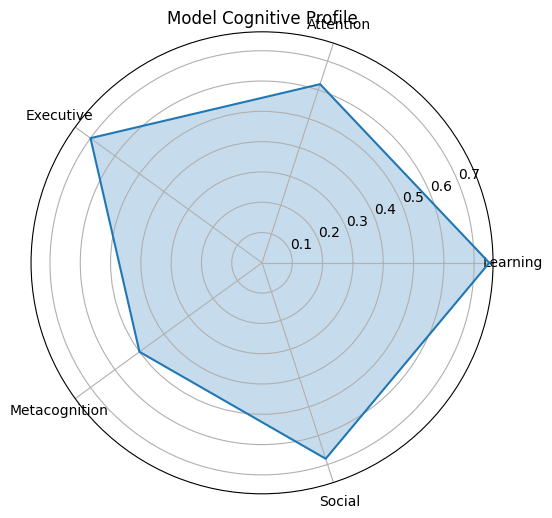

In [9]:
labels = list(scores.keys())
values = list(scores.values())

angles = np.linspace(0,2*np.pi,len(labels),endpoint=False)

values = np.concatenate((values,[values[0]]))
angles = np.concatenate((angles,[angles[0]]))

fig = plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)

ax.plot(angles,values)
ax.fill(angles,values,alpha=0.25)

ax.set_thetagrids(angles[:-1]*180/np.pi,labels)

plt.title("Model Cognitive Profile")
plt.show()

# 11. Comparing Multiple Models

We can compare models using a heatmap showing performance across faculties.

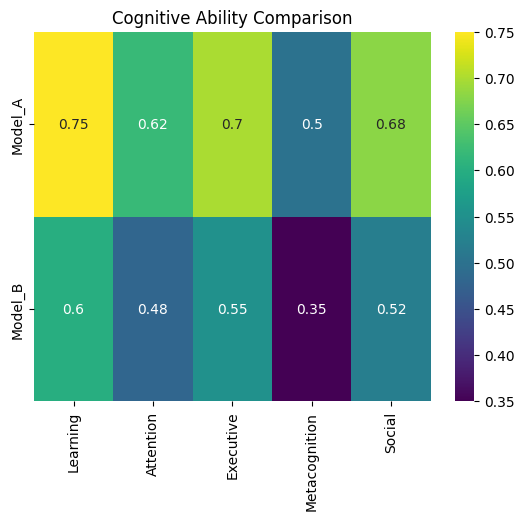

In [10]:
data = pd.DataFrame({
"Learning":[0.75,0.60],
"Attention":[0.62,0.48],
"Executive":[0.70,0.55],
"Metacognition":[0.50,0.35],
"Social":[0.68,0.52]
},index=["Model_A","Model_B"])

sns.heatmap(data,annot=True,cmap="viridis")

plt.title("Cognitive Ability Comparison")
plt.show()

# 12. Conclusion

This notebook demonstrates how **procedural benchmarks** can be used to measure cognitive abilities of AI systems.

Key contributions:

• Procedural task generators for five cognitive faculties  
• Benchmark dataset generation  
• Evaluation framework  
• Cognitive profile visualization  

Rather than producing a single accuracy score, this approach produces a **multi-dimensional cognitive profile**, revealing the specific strengths and weaknesses of AI models.

Such benchmarks provide a more meaningful way to measure progress toward **Artificial General Intelligence (AGI)**.